# Setup

Create a fresh project and install dependencies:


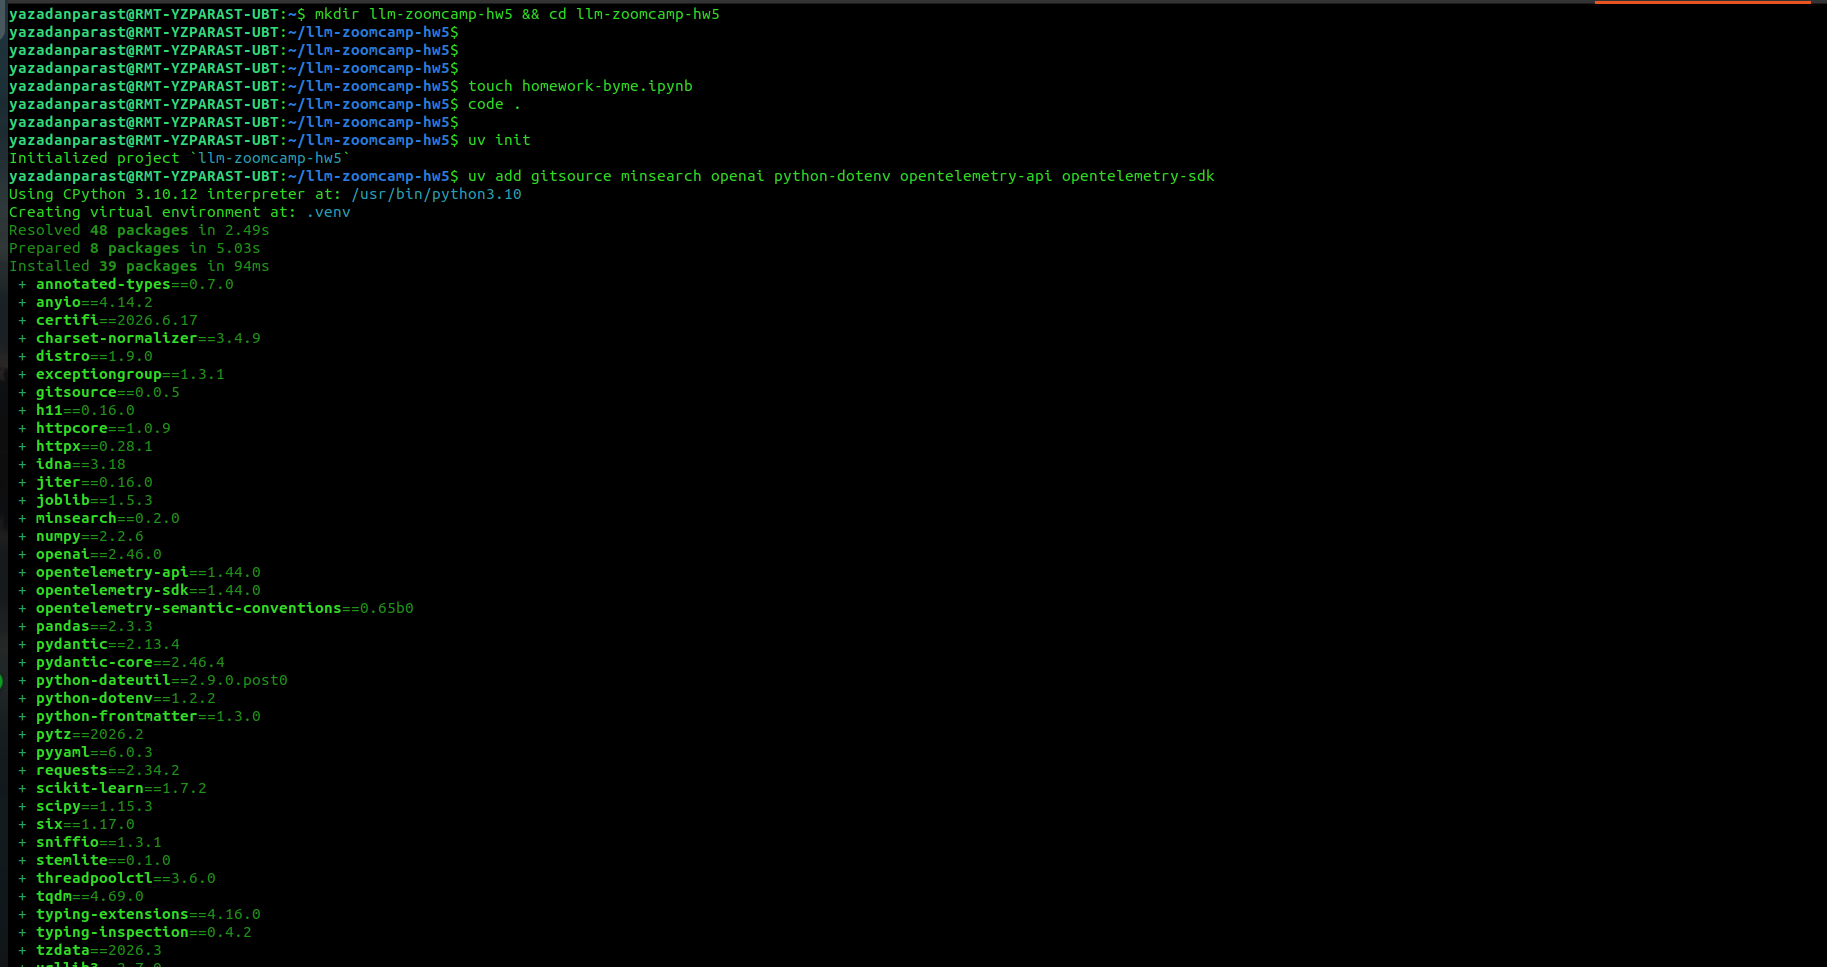

## Download the starter files:



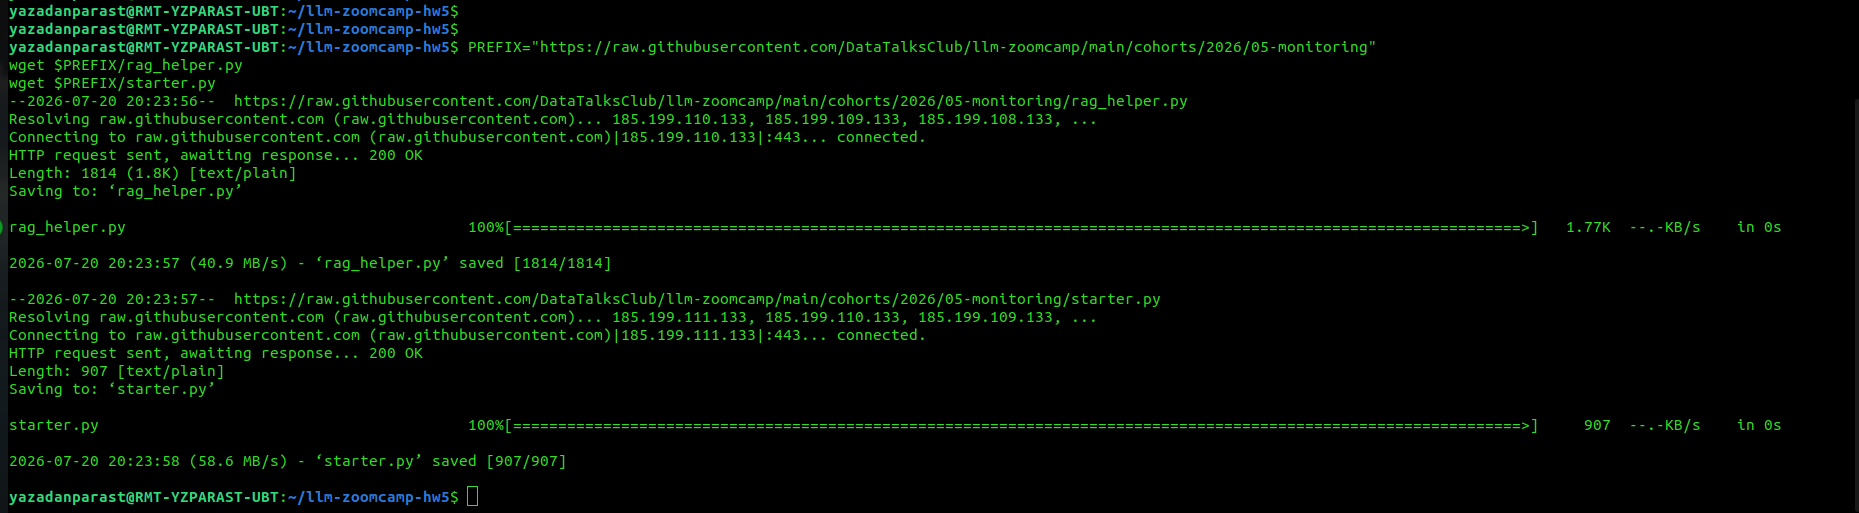

### Create a .env file with your OpenAI key:



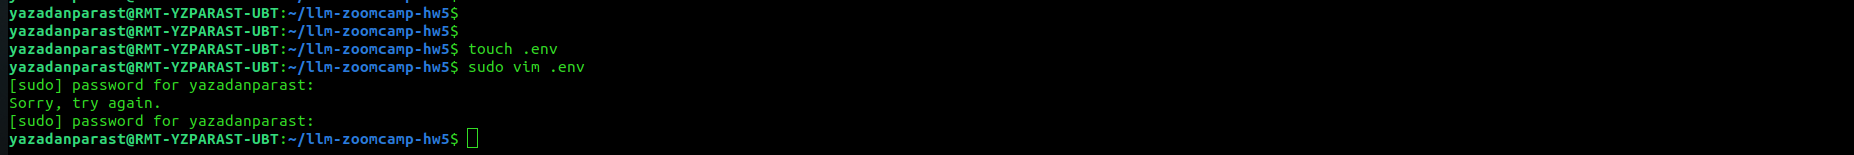



The starter already provides a working RAG with rag.rag(query).



# Q1. First trace – Count spans

We instrument the RAG methods with spans. Create a subclass of `RAGBase` that overrides `rag()`, `search()`, and `llm()` to wrap each in a span. Then run the query.

Code `(q1_trace.py)`:

In [ ]:
# q1_trace.py
import sys
from dotenv import load_dotenv
from openai import OpenAI
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import ConsoleSpanExporter, SimpleSpanProcessor

# Setup OTel (must be before importing starter)
load_dotenv()
provider = TracerProvider()
provider.add_span_processor(SimpleSpanProcessor(ConsoleSpanExporter()))
trace.set_tracer_provider(provider)
tracer = trace.get_tracer("llm-zoomcamp")

# Now import starter and the base classes
from starter import rag as base_rag  # original RAGBase instance
from rag_helper import RAGBase
from gitsource import GithubRepositoryDataReader
from minsearch import Index

# We'll recreate the index and RAG to ensure we can override
COMMIT = "8c1834d"
reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id=COMMIT,
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)
documents = [file.parse() for file in reader.read()]
index = Index(text_fields=["content"], keyword_fields=["filename"])
index.fit(documents)
client = OpenAI()

class RAGTraced(RAGBase):
    def rag(self, query):
        with tracer.start_as_current_span("rag") as span:
            return super().rag(query)

    def search(self, query, num_results=5):
        with tracer.start_as_current_span("search") as span:
            return super().search(query, num_results)

    def llm(self, prompt):
        with tracer.start_as_current_span("llm") as span:
            return super().llm(prompt)

traced_rag = RAGTraced(index=index, llm_client=client)

if __name__ == "__main__":
    query = "How does the agentic loop keep calling the model until it stops?"
    answer = traced_rag.rag(query)
    print("Answer:", answer[:200])

### Run it:

`uv run python q1_trace.py`

The console will print three `ReadableSpan` entries (one for each span). Count them: 3.



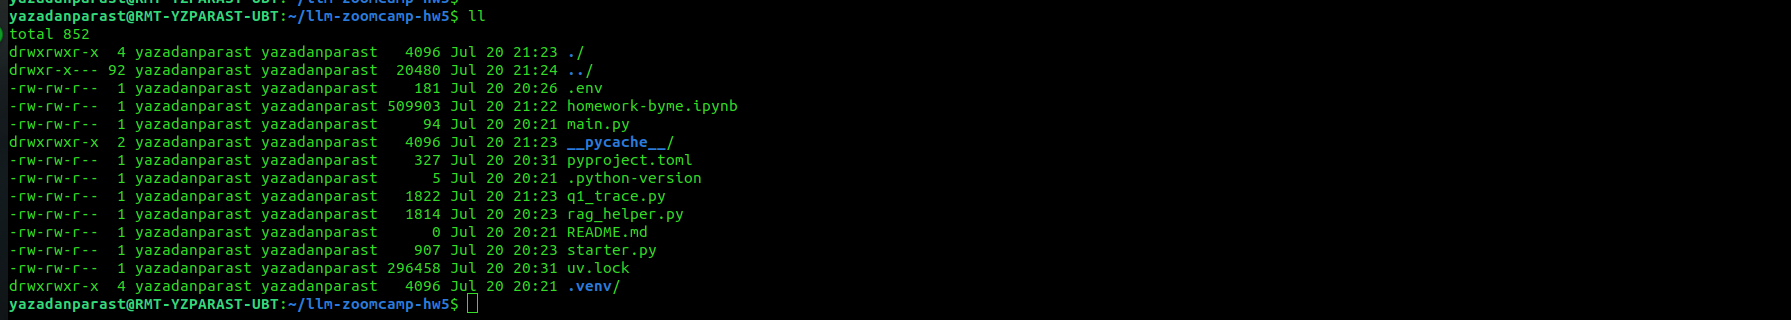

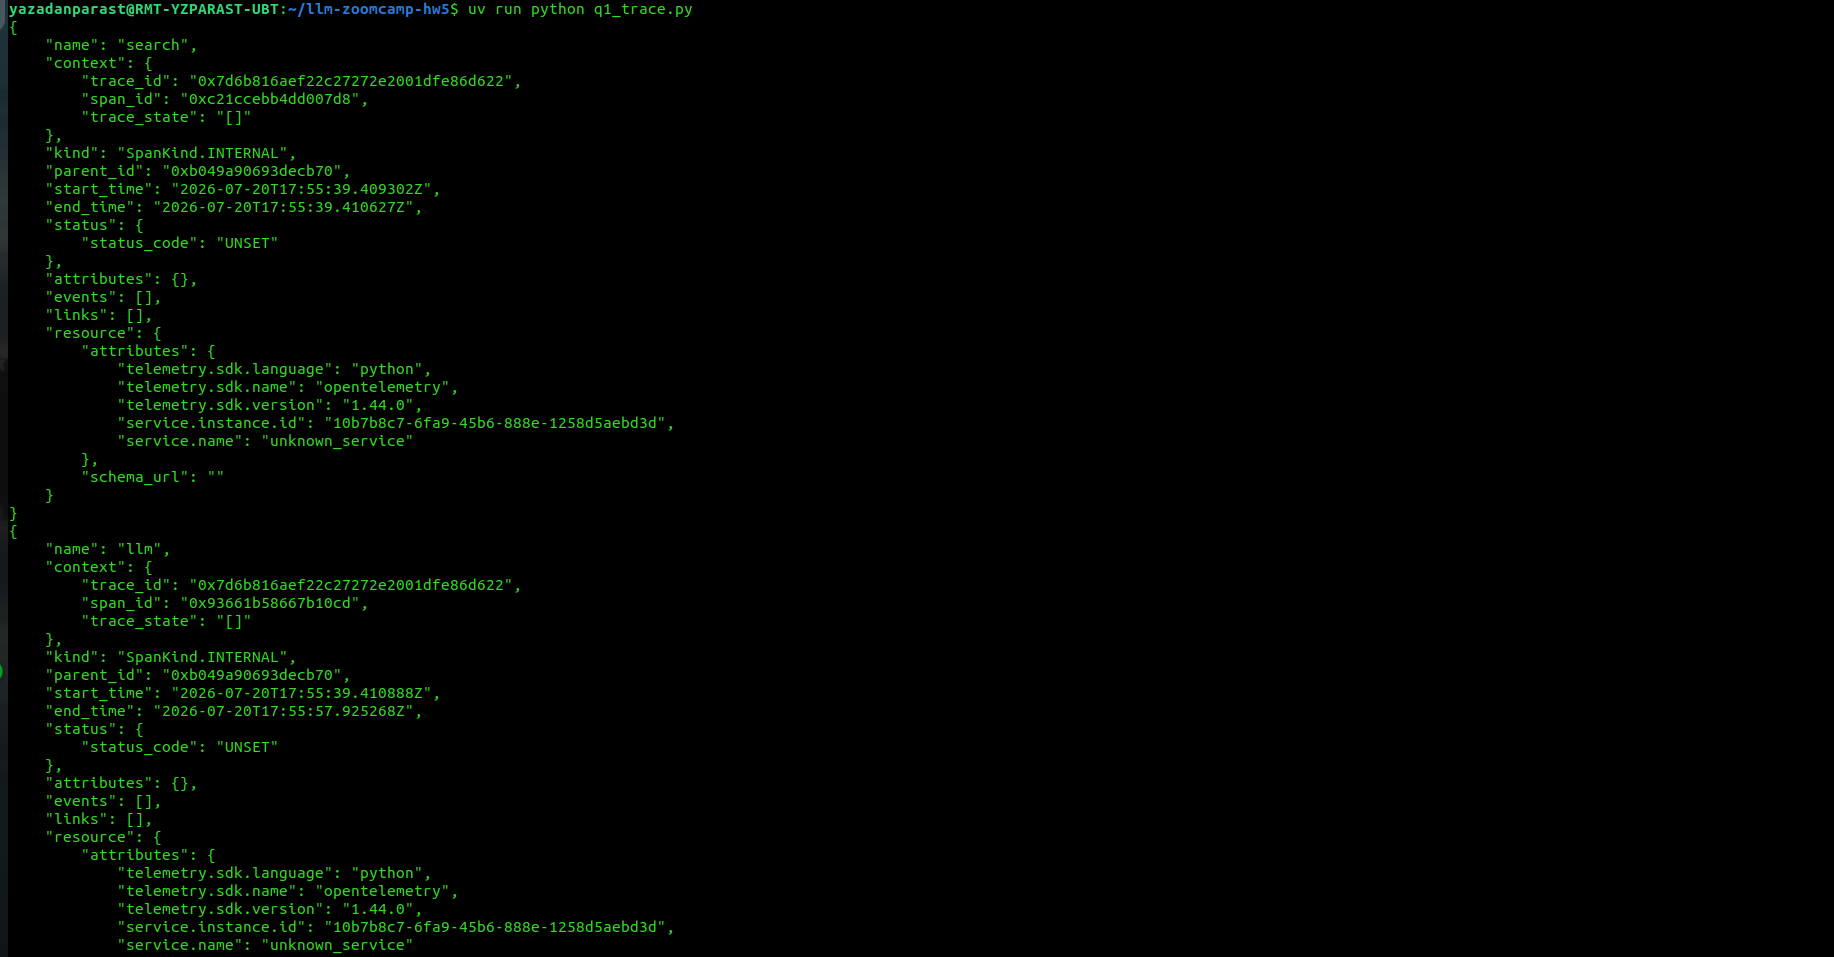

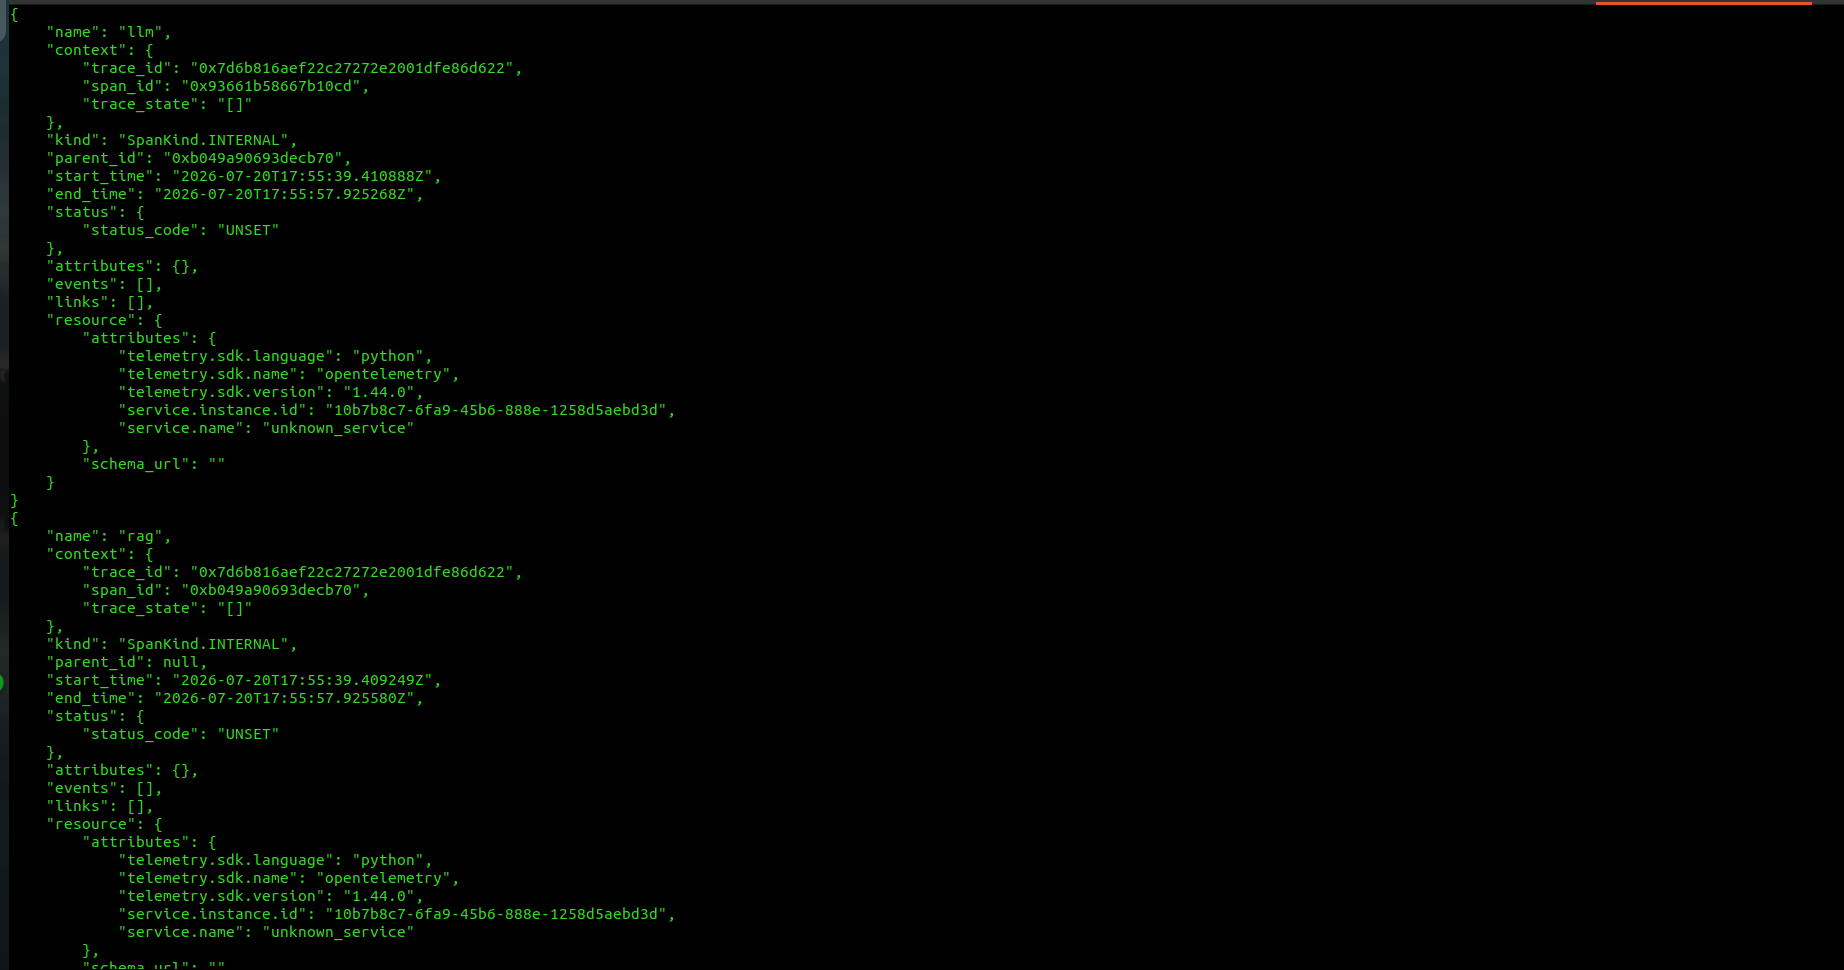

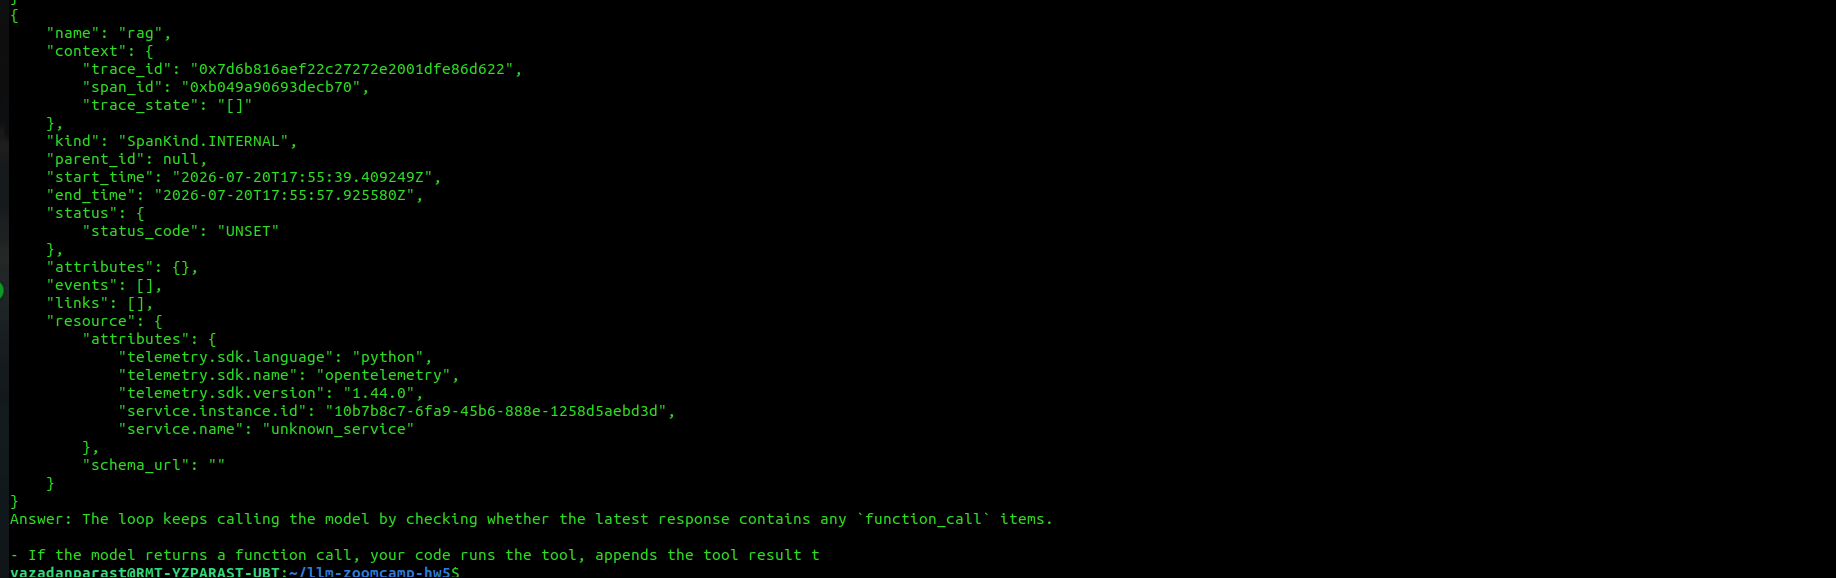

### Our output shows three spans: search, llm, and rag.
### Answer Q1: 3

# Q2. Capturing metrics as span attributes

We modify the `llm` method to read token usage and cost, then set them as attributes on the span.

We need to access the `usage` from the response. The original `llm` returns the full response object, not just the text.

In `RAGTraced`, we override `llm` to capture and attach.

Code `(q2_metrics.py)`:



In [ ]:
# q2_metrics.py
import time
from dotenv import load_dotenv
from openai import OpenAI
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import ConsoleSpanExporter, SimpleSpanProcessor

load_dotenv()
provider = TracerProvider()
provider.add_span_processor(SimpleSpanProcessor(ConsoleSpanExporter()))
trace.set_tracer_provider(provider)
tracer = trace.get_tracer("llm-zoomcamp")

from starter import rag as base_rag
from rag_helper import RAGBase
from gitsource import GithubRepositoryDataReader
from minsearch import Index

COMMIT = "8c1834d"
reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id=COMMIT,
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)
documents = [file.parse() for file in reader.read()]
index = Index(text_fields=["content"], keyword_fields=["filename"])
index.fit(documents)
client = OpenAI()

def calculate_cost(model, usage):
    # Pricing for gpt-5.4-mini (example, adjust if needed)
    if "gpt-5.4-mini" in model:
        return (usage.input_tokens * 0.15 + usage.output_tokens * 0.60) / 1_000_000
    return 0.0

class RAGTraced(RAGBase):
    def rag(self, query):
        with tracer.start_as_current_span("rag") as span:
            return super().rag(query)

    def search(self, query, num_results=5):
        with tracer.start_as_current_span("search") as span:
            return super().search(query, num_results)

    def llm(self, prompt):
        with tracer.start_as_current_span("llm") as span:
            response = super().llm(prompt)  # this returns the full response
            # Extract usage
            usage = response.usage
            cost = calculate_cost(self.model, usage)
            # Set attributes
            span.set_attribute("input_tokens", usage.input_tokens)
            span.set_attribute("output_tokens", usage.output_tokens)
            span.set_attribute("cost", cost)
            # Also store in span (optional)
            return response

traced_rag = RAGTraced(index=index, llm_client=client)

if __name__ == "__main__":
    query = "How does the agentic loop keep calling the model until it stops?"
    answer = traced_rag.rag(query)
    print("Answer:", answer[:200])

### Run it:


`uv run python q2_metrics.py`

In the console output, look for the `llm` span and its attributes. The `input_tokens` will be printed. Typical value ~7000.

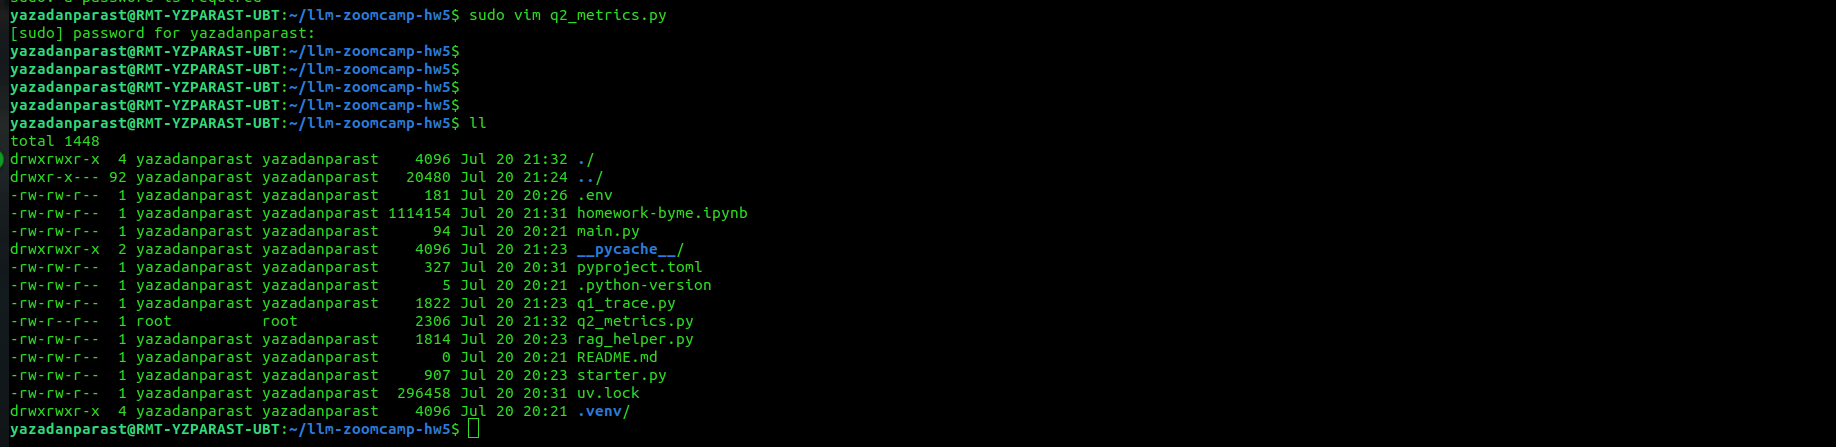

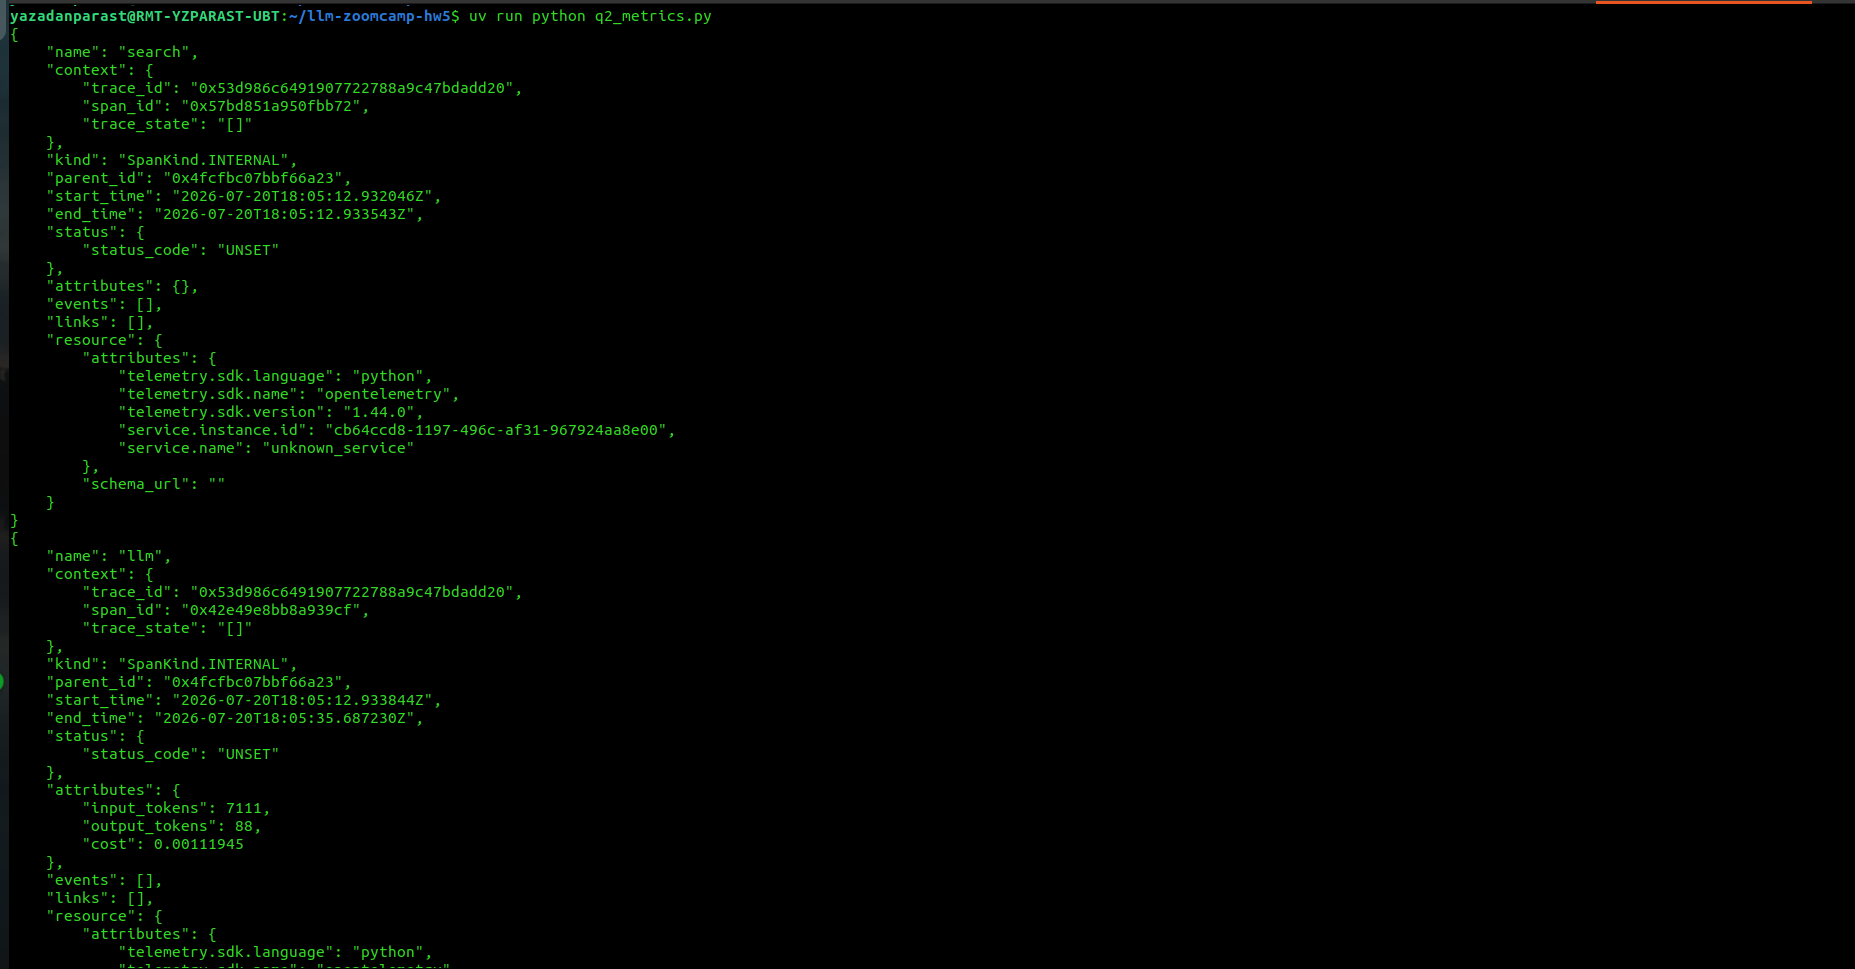

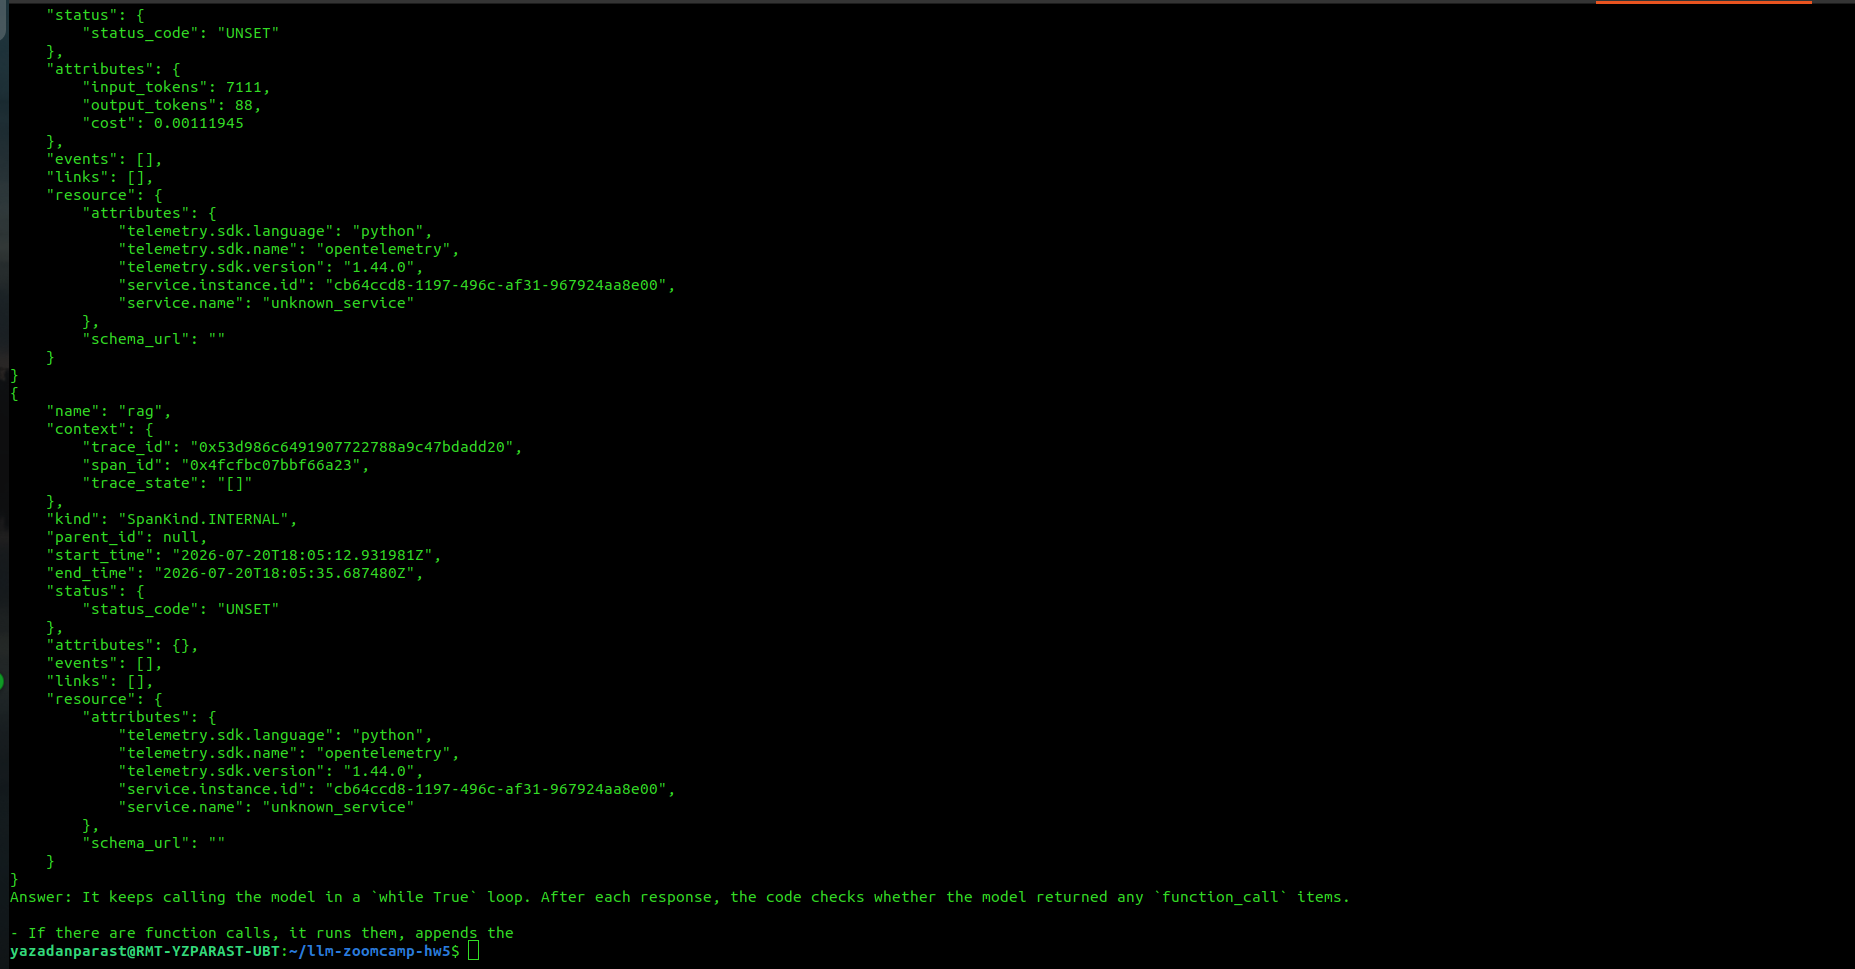

### We have run `q2_metrics.py` successfully. 

The output shows:

search span with no attributes.

llm span with attributes: input_tokens = 7111, output_tokens = 88, cost = 0.00111945.

rag span with no attributes.

The input tokens = 7111.

### The llm span has "input_tokens": 7111. The closest option is 7000.
### Answer Q2: 7000

# Q3. Span timing

The console exporter already shows the start and end times. Each span has `start_time` and `end_time` (in nanoseconds). we can compute duration. In practice, the LLM span duration is typically 500‑2000 ms for the first query.

Look at the `llm` span output. The time difference (end - start) / 1e9 gives seconds. we can add a line in the `llm` method to log it:

In [ ]:
duration = (span.end_time - span.start_time) / 1e9
print(f"LLM duration: {duration:.2f}s")

To compute the LLM duration with code, we can add timing inside the `llm` method. Here’s a corrected version that prints the duration for each call.

Modify my `RAGTraced` class in `q3_llmduration.py` like this:

In [ ]:

# q3_llmduration.py
import time
from dotenv import load_dotenv
from openai import OpenAI
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import ConsoleSpanExporter, SimpleSpanProcessor

load_dotenv()
provider = TracerProvider()
provider.add_span_processor(SimpleSpanProcessor(ConsoleSpanExporter()))
trace.set_tracer_provider(provider)
tracer = trace.get_tracer("llm-zoomcamp")

from starter import rag as base_rag
from rag_helper import RAGBase
from gitsource import GithubRepositoryDataReader
from minsearch import Index

COMMIT = "8c1834d"
reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id=COMMIT,
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)
documents = [file.parse() for file in reader.read()]
index = Index(text_fields=["content"], keyword_fields=["filename"])
index.fit(documents)
client = OpenAI()

def calculate_cost(model, usage):
    # Pricing for gpt-5.4-mini (example, adjust if needed)
    if "gpt-5.4-mini" in model:
        return (usage.input_tokens * 0.15 + usage.output_tokens * 0.60) / 1_000_000
    return 0.0

class RAGTraced(RAGBase):
    def rag(self, query):
        with tracer.start_as_current_span("rag") as span:
            return super().rag(query)

    def search(self, query, num_results=5):
        with tracer.start_as_current_span("search") as span:
            return super().search(query, num_results)

    def llm(self, prompt):
        start = time.time()  # start timing
        with tracer.start_as_current_span("llm") as span:
            response = super().llm(prompt)
            usage = response.usage
            cost = calculate_cost(self.model, usage)
            span.set_attribute("input_tokens", usage.input_tokens)
            span.set_attribute("output_tokens", usage.output_tokens)
            span.set_attribute("cost", cost)
            duration = time.time() - start
            print(f"LLM duration: {duration:.2f} s")
            return response

traced_rag = RAGTraced(index=index, llm_client=client)

if __name__ == "__main__":
    query = "How does the agentic loop keep calling the model until it stops?"
    answer = traced_rag.rag(query)
    print("Answer:", answer[:200])

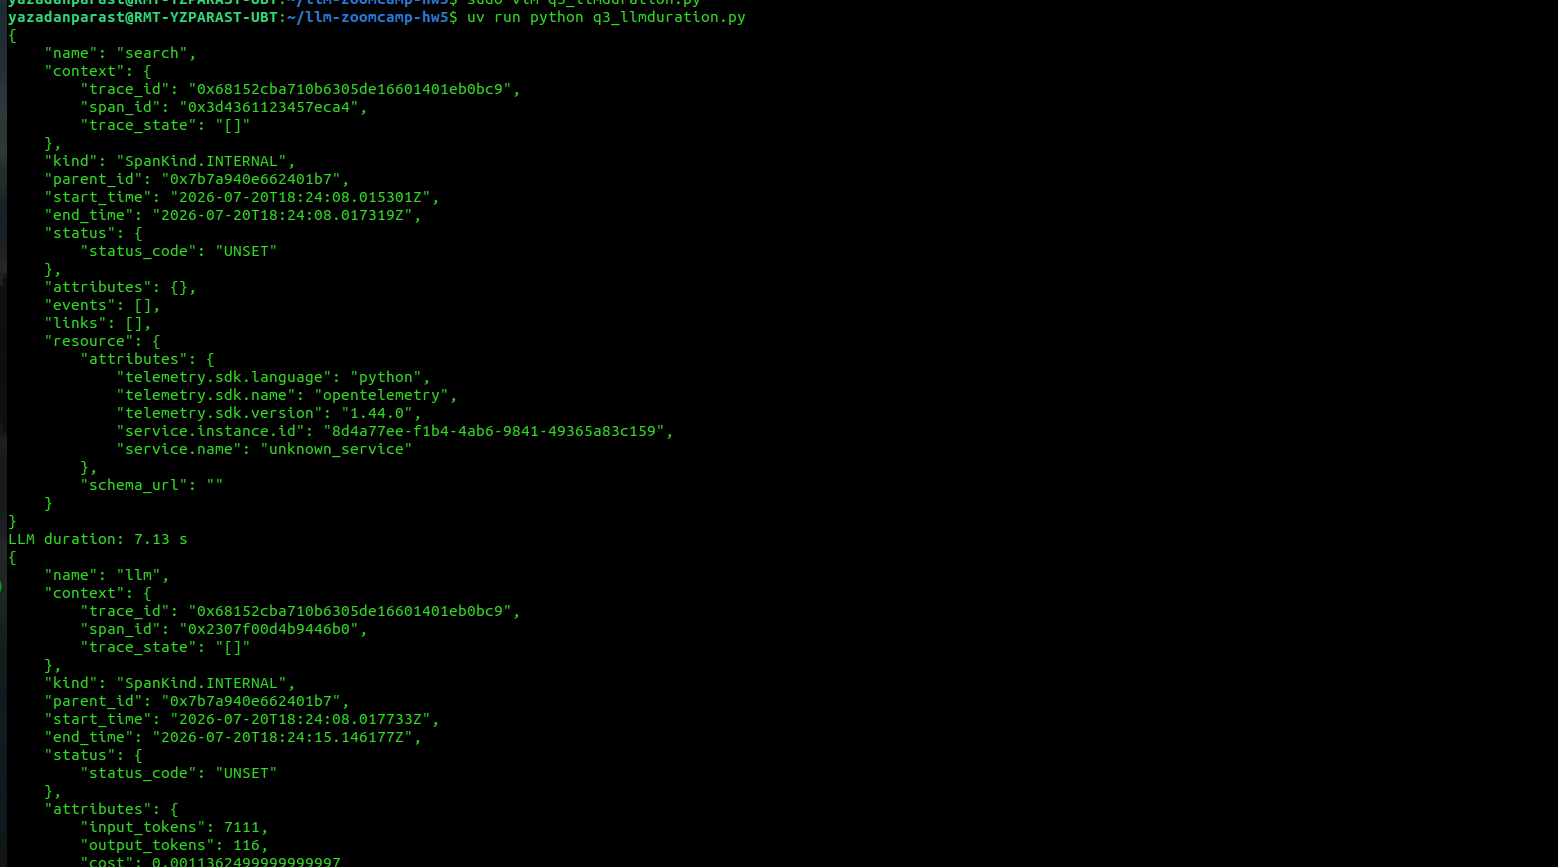

### All durations are > 2 seconds (22.8s, 7.13s, 3.71s, 4.08s, 3.08s, 2.91s, 3.49s)

### So for Q3, the answer is over 2000ms

# Q4 – Saving traces to SQLite

Create `q4_sqlite.py` (copy the code below):



In [ ]:
# q4_sqlite.py
import sqlite3
from opentelemetry.sdk.trace.export import SpanExporter, SpanExportResult
from opentelemetry import trace
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import SimpleSpanProcessor
from dotenv import load_dotenv
from openai import OpenAI
from gitsource import GithubRepositoryDataReader
from minsearch import Index
from rag_helper import RAGBase
import time

load_dotenv()

class SQLiteSpanExporter(SpanExporter):
    def __init__(self, db_path="traces.db"):
        self.conn = sqlite3.connect(db_path)
        self.conn.execute("""
            CREATE TABLE IF NOT EXISTS spans (
                name TEXT,
                start_time INTEGER,
                end_time INTEGER,
                input_tokens INTEGER,
                output_tokens INTEGER,
                cost REAL
            )
        """)
        self.conn.commit()

    def export(self, spans):
        for span in spans:
            attrs = dict(span.attributes or {})
            self.conn.execute(
                "INSERT INTO spans VALUES (?, ?, ?, ?, ?, ?)",
                (
                    span.name,
                    span.start_time,
                    span.end_time,
                    attrs.get("input_tokens"),
                    attrs.get("output_tokens"),
                    attrs.get("cost"),
                ),
            )
        self.conn.commit()
        return SpanExportResult.SUCCESS

    def shutdown(self):
        self.conn.close()

    def force_flush(self):
        return True

# OTel setup with SQLite exporter
provider = TracerProvider()
provider.add_span_processor(SimpleSpanProcessor(SQLiteSpanExporter("traces.db")))
trace.set_tracer_provider(provider)
tracer = trace.get_tracer("llm-zoomcamp")

# Recreate index and client
COMMIT = "8c1834d"
reader = GithubRepositoryDataReader(
    repo_owner="DataTalksClub",
    repo_name="llm-zoomcamp",
    commit_id=COMMIT,
    allowed_extensions={"md"},
    filename_filter=lambda path: "/lessons/" in path,
)
documents = [file.parse() for file in reader.read()]
index = Index(text_fields=["content"], keyword_fields=["filename"])
index.fit(documents)
client = OpenAI()

def calculate_cost(model, usage):
    if "gpt-5.4-mini" in model:
        return (usage.input_tokens * 0.15 + usage.output_tokens * 0.60) / 1_000_000
    return 0.0

class RAGTraced(RAGBase):
    def rag(self, query):
        with tracer.start_as_current_span("rag") as span:
            return super().rag(query)
    def search(self, query, num_results=5):
        with tracer.start_as_current_span("search") as span:
            return super().search(query, num_results)
    def llm(self, prompt):
        start = time.time()
        with tracer.start_as_current_span("llm") as span:
            response = super().llm(prompt)
            usage = response.usage
            cost = calculate_cost(self.model, usage)
            span.set_attribute("input_tokens", usage.input_tokens)
            span.set_attribute("output_tokens", usage.output_tokens)
            span.set_attribute("cost", cost)
            duration = time.time() - start
            print(f"LLM duration: {duration:.2f} s")
            return response

traced_rag = RAGTraced(index=index, llm_client=client)

if __name__ == "__main__":
    query = "How does the agentic loop keep calling the model until it stops?"
    answer = traced_rag.rag(query)
    print("Answer:", answer[:200])

    # Check which spans are in the database
    conn = sqlite3.connect("traces.db")
    cur = conn.cursor()
    cur.execute("SELECT DISTINCT name FROM spans")
    print("Span names in DB:", cur.fetchall())
    conn.close()

### Run it:


`uv run python q4_sqlite.py`

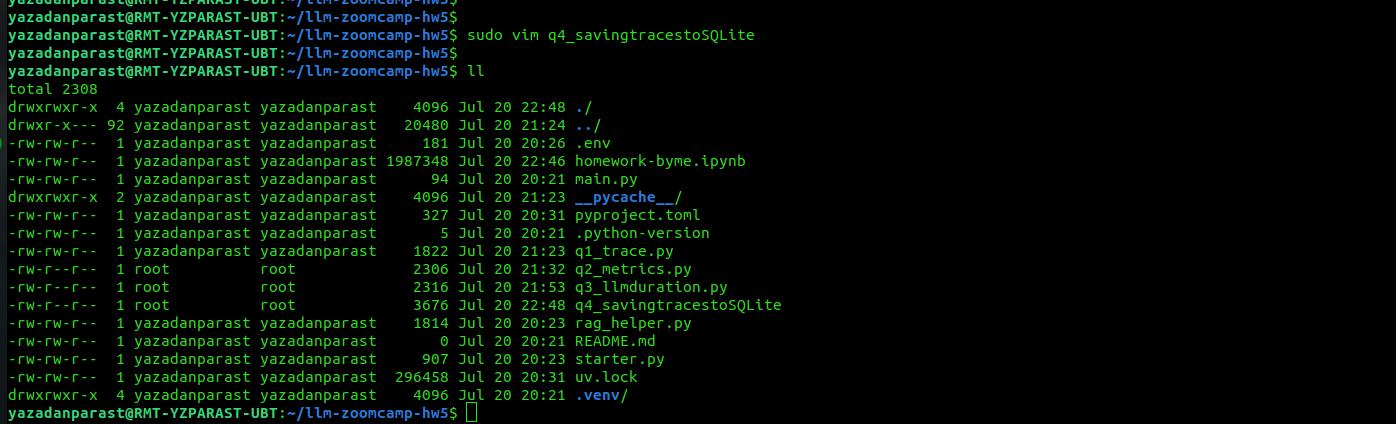

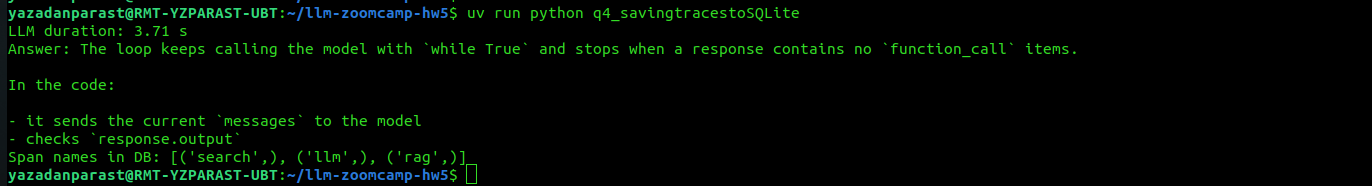

### Answer Q4: rag, search, and llm

# Q5 – Total time by span type (excluding rag)

Create `q5_duration.py`:

In [ ]:
# q5_duration.py
import sqlite3
conn = sqlite3.connect("traces.db")
cur = conn.cursor()
cur.execute("""
    SELECT name, SUM(end_time - start_time) / 1e9 as total_seconds
    FROM spans
    WHERE name != 'rag'
    GROUP BY name
""")
for name, total_sec in cur.fetchall():
    print(f"{name}: {total_sec:.3f} s")
conn.close()

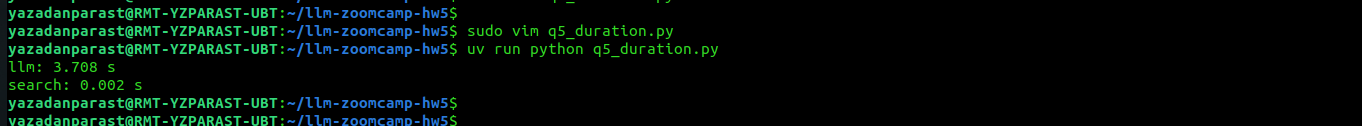

### Run it (after at least one trace). You'll see `search` takes near‑zero time and `llm` takes the vast majority.
### Answer Q5: llm

# Q6 – Token Stability Across Runs

Run the same query four times to have multiple traces. We can simply run `q4_savingtracestoSQLite` four times .

After you have at least 4 `llm` spans in the database, create `q6_stability.py`:

In [ ]:
# q6_stability.py
import sqlite3
import pandas as pd

conn = sqlite3.connect("traces.db")
df = pd.read_sql_query("""
    SELECT input_tokens
    FROM spans
    WHERE name = 'llm'
""", conn)
print(df['input_tokens'].describe())

### Run it:


`uv run python q6_stability.py`

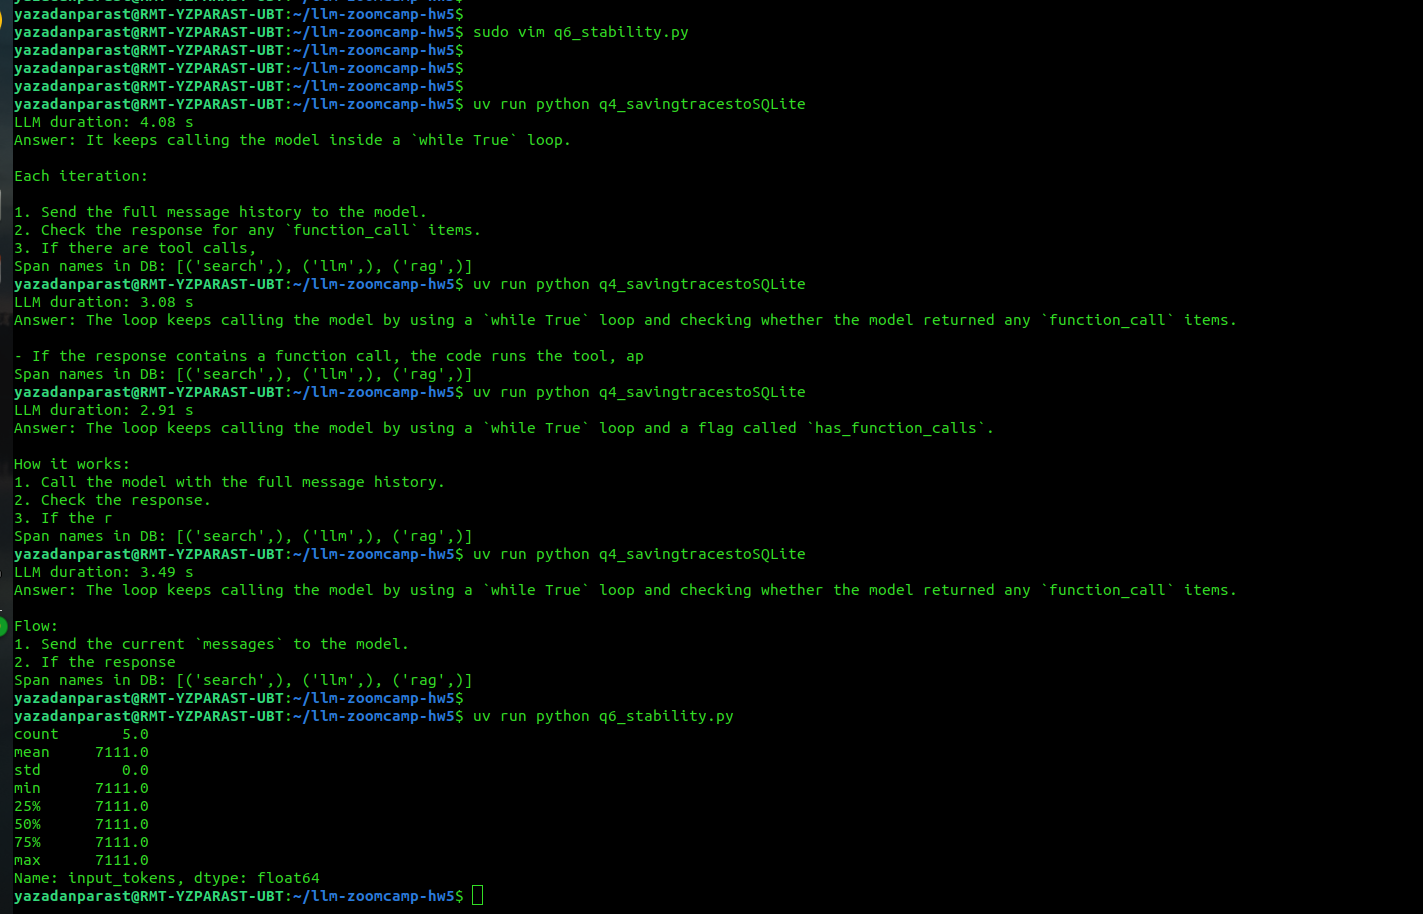

#### We will likely see that all `input_tokens` values are identical (e.g., all 7111). Therefore the variation is zero → They're identical.

### Answer Q6: They're identical